# Method 34 - Polar stereographic projection, 99th percentile 1980-2000 and 93.5th percentile 2000-2023 random sampling overflow bins and month distribution average cap

with overcomplete Autoencoder ie latent dimension larger than imput size

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import plotly.express as px
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm
from funcs import profileNo_vs_xy_bins, sample_cap_bins_xy, plot_geo, plot_heatmap_npts_xy, plot_3d, cross_sec_lon, cross_sec_lon_prob

2026-04-24 17:16:07.472112: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980] # remove the few points before 1980 (only 7 points)
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month']]

In [3]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [4]:
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]']

In [5]:
# Break into two parts (1980-2000 and 2000-2023)
df_80_00 = df_ST[(df_ST['year'] >= 1980) & (df_ST['year'] < 2000)]
df_00_23 = df_ST[(df_ST['year'] >= 2000) & (df_ST['year'] < 2023)]

In [6]:
threshold_0 = profileNo_vs_xy_bins(df_80_00, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.99, projection='npstere')

In [7]:
threshold_1 = profileNo_vs_xy_bins(df_00_23, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.935, projection='npstere')

In [8]:
df_sampled_0 = sample_cap_bins_xy(df_80_00, thresh=threshold_0, n_x_bins=100, n_y_bins=100)
df_sampled_1 = sample_cap_bins_xy(df_00_23, thresh=threshold_1, n_x_bins=100, n_y_bins=100)
df_sampled = pd.concat([df_sampled_0, df_sampled_1], ignore_index=True)

In [9]:
# cap monthly distribution to average for whole sampled set
monthly_counts = df_sampled.groupby('month').size()
average_monthly_count = monthly_counts.mean()
df_sampled = df_sampled.groupby('month').apply(lambda x: x.sample(n=int(average_monthly_count), random_state=seed) if len(x) > average_monthly_count else x).reset_index(drop=True)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_26398/754394473.py:4: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [10]:
# Scale data
scaler = StandardScaler()
df_ST_scaled = scaler.fit_transform(df_sampled[features])

In [11]:
# set seed for reproducibility
tf.random.set_seed(seed)

# Autoencoder architecture
input_dim = df_ST_scaled.shape[1]
latent_dim = 5

# Encoder
inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(16, activation='relu')(inputs)
x = layers.Dense(8, activation='relu')(x)
latent = layers.Dense(latent_dim, name="latent")(x)

# Decoder
x = layers.Dense(8, activation='relu')(latent)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(input_dim)(x)

autoencoder = models.Model(inputs, outputs)
encoder = models.Model(inputs, latent)

In [12]:
early_stopping = EarlyStopping(
    monitor='val_loss',   # validation loss checked for early stopping
    patience=5,           # how many epochs to wait before stopping
    restore_best_weights=True)

autoencoder.compile(
    optimizer='adam',
    loss='mse')

autoencoder.fit(
    df_ST_scaled,
    df_ST_scaled,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1)

Epoch 1/50
78277/78277 ━━━━━━━━━━━━━━━━━━━━ 93s 1ms/step - loss: 0.0011 - val_loss: 4.6466e-06
Epoch 2/50
78277/78277 ━━━━━━━━━━━━━━━━━━━━ 96s 1ms/step - loss: 1.1485e-05 - val_loss: 1.8992e-07
Epoch 3/50
78277/78277 ━━━━━━━━━━━━━━━━━━━━ 91s 1ms/step - loss: 1.0927e-05 - val_loss: 2.3436e-07
Epoch 4/50
78277/78277 ━━━━━━━━━━━━━━━━━━━━ 91s 1ms/step - loss: 8.8907e-06 - val_loss: 2.5564e-07
Epoch 5/50
78277/78277 ━━━━━━━━━━━━━━━━━━━━ 91s 1ms/step - loss: 8.1702e-06 - val_loss: 3.4653e-07
Epoch 6/50
78277/78277 ━━━━━━━━━━━━━━━━━━━━ 93s 1ms/step - loss: 8.1239e-06 - val_loss: 2.0157e-07
Epoch 7/50
78277/78277 ━━━━━━━━━━━━━━━━━━━━ 94s 1ms/step - loss: 6.1379e-06 - val_loss: 3.0587e-07
Epoch 8/50
78277/78277 ━━━━━━━━━━━━━━━━━━━━ 93s 1ms/step - loss: 6.0434e-06 - val_loss: 5.7314e-08
Epoch 9/50
78277/78277 ━━━━━━━━━━━━━━━━━━━━ 92s 1ms/step - loss: 6.2296e-06 - val_loss: 2.4262e-06
Epoch 10/50
78277/78277 ━━━━━━━━━━━━━━━━━━━━ 92s 1ms/step - loss: 5.4512e-06 - val_loss: 1.0244e-07
Epoch 11/50
7

In [13]:
X_latent = encoder.predict(df_ST_scaled)

173947/173947 ━━━━━━━━━━━━━━━━━━━━ 2139s 12ms/step


In [14]:
# Four clusters to compare with other methods
n_clusters = 4

In [15]:
gmm = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(X_latent)

In [16]:
df_sampled['gmm_label_4'] = labels

/Users/franciscagomes/PhD/WM_class/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.



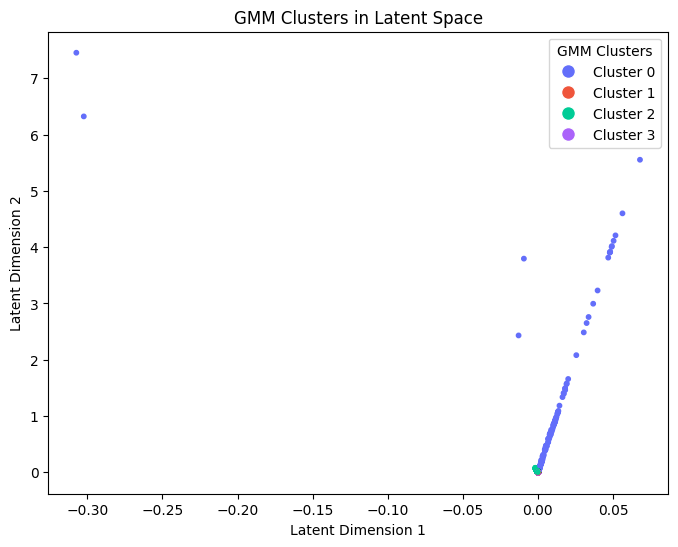

In [17]:
# Plot the 4 clusters in the latent space
plt.figure(figsize=(8, 6))
cmap = ListedColormap(px.colors.qualitative.Plotly[:n_clusters])
norm = BoundaryNorm(boundaries=np.arange(-0.5, n_clusters + 0.5, 1), ncolors=n_clusters)
plt.scatter(X_latent[:, 0], X_latent[:, 1], c=labels, cmap=cmap, norm=norm, s=10)
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('GMM Clusters in Latent Space')
legend_elements = [Line2D([0], [0], marker='o', color='w', label=f'Cluster {i}', markerfacecolor=cmap(i), markersize=10) for i in range(n_clusters)]
plt.legend(handles=legend_elements, title='GMM Clusters')
plt.show()

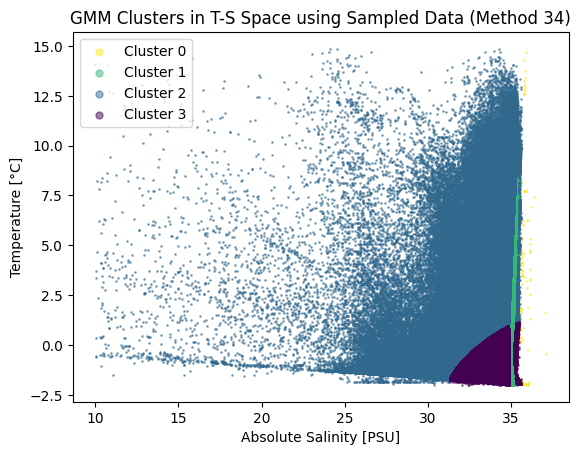

In [18]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_4'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 34)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [19]:
# Sample geographically for better plotting
df_sampled_plot = df_sampled.sample(n=70000, random_state=seed)
plot_geo(df_sampled_plot, n_clusters)

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Paper1/TS_M34/funcs.py:625: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



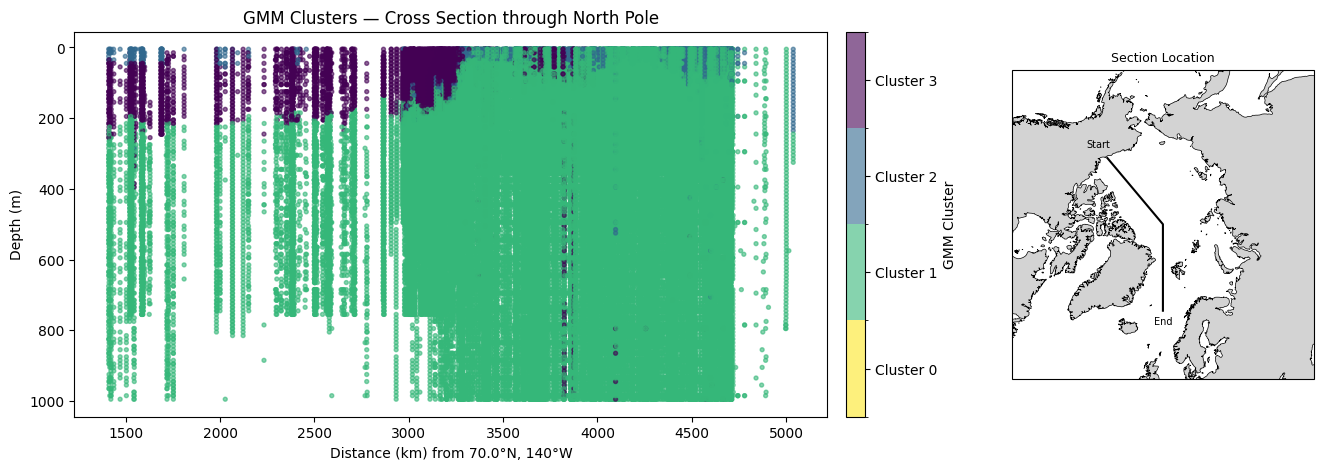

In [20]:
cross_sec_lon(df_sampled, n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

In [21]:
# Get probabilities for each cluster
for i in range(n_clusters):
    df_sampled[f'prob_cluster_{i}'] = gmm.predict_proba(X_latent)[:, i]

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Paper1/TS_M34/funcs.py:717: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



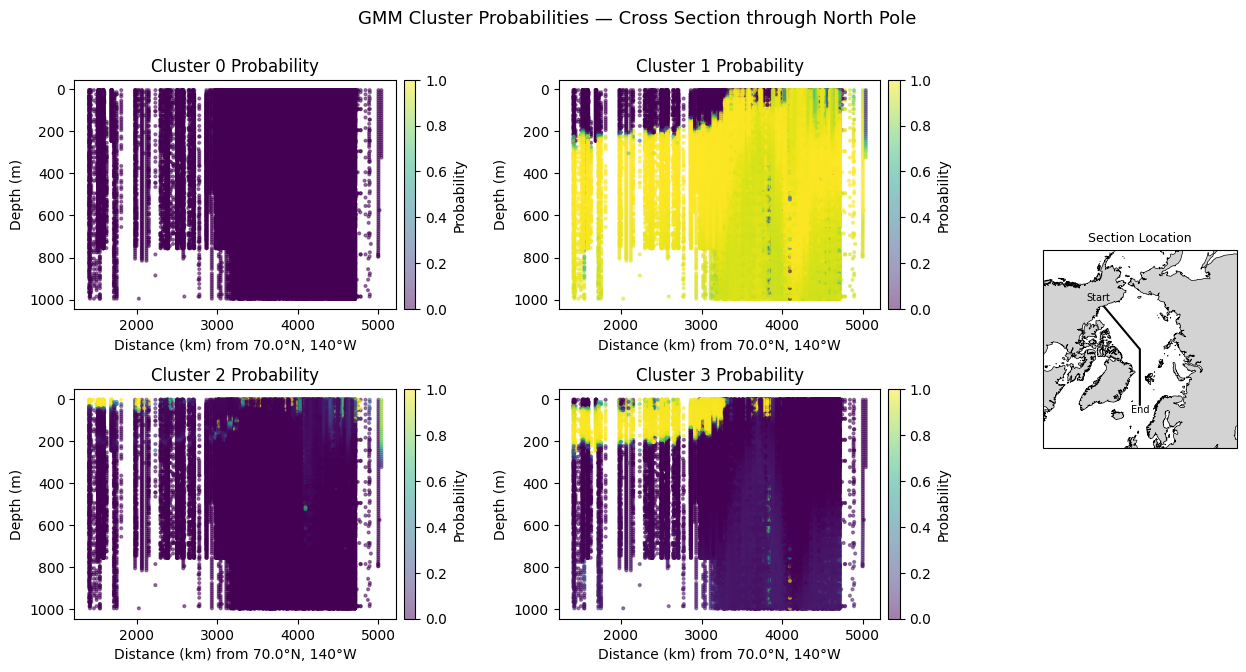

In [22]:
cross_sec_lon_prob(df_sampled, -180, tol=0.5, start_lat=70.0, start_lon=-140)